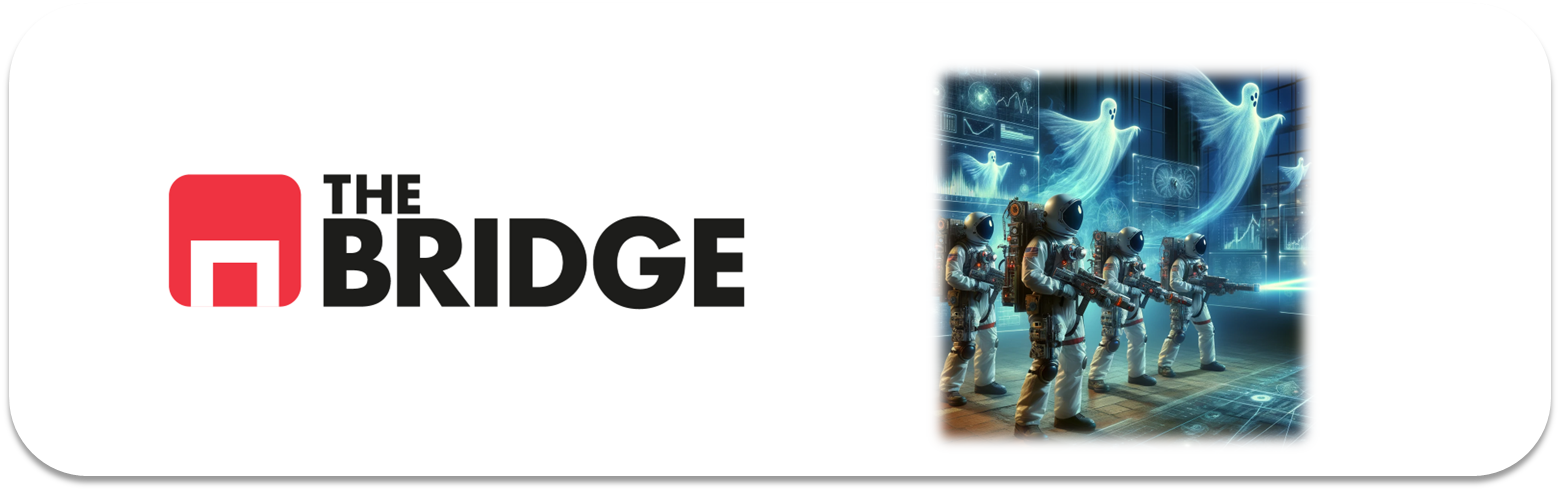

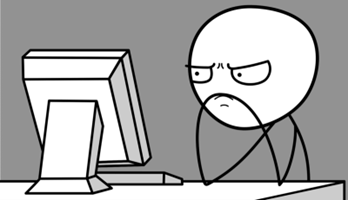

Para ejercitarte y afianzar lo aprendido sobre **Series Temporales**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### El "problema"

Para este ejercicio vamos a predecir cuál será la demanda de pasajeros de una aerolinea, para poder anticiparse a las contrataciones de personal, mantenimiento de las aeronaves y gestión de inventario y comidas.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.base import clone
from threadpoolctl import threadpool_limits
threadpool_limits(2)
SEED=42
np.random.seed(SEED)
ROOT=next(p for p in Path.cwd().parents if (p/'05_Deep_Learning').exists() and (p/'.git').exists())
CACHE=ROOT/'.cache'/'unidades_siguientes'
CACHE.mkdir(parents=True,exist_ok=True)
os.environ['KERAS_HOME']=str(CACHE/'keras')
os.environ['KAGGLEHUB_CACHE']=str(CACHE/'kaggle')
os.environ['TF_CPP_MIN_LOG_LEVEL']='2'
from statsmodels.tsa.stattools import adfuller,kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import root_mean_squared_error,mean_absolute_percentage_error

### Ejercicio 1

Carga los datos y adecúa el dataset teniendo en cuenta que es una serie temporal. Para ello convierte la columna de fecha al formato adecuado y luego úsala como índice.

In [2]:
df=pd.read_csv('data/AirPassengers.csv',parse_dates=['date']).set_index('date').sort_index()
y=df['value'].asfreq('MS')
assert not y.isna().any()
display(y.head())

date
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Freq: MS, Name: value, dtype: int64

### Ejercicio 2

¿De qué fecha a qué fecha va el histórico?¿Qué periodicidad tiene la serie?

In [3]:
print('Inicio:',y.index.min(),'Fin:',y.index.max(),'Frecuencia:',pd.infer_freq(y.index),'N:',len(y))

Inicio: 1949-01-01 00:00:00 Fin: 1960-12-01 00:00:00 Frecuencia: MS N: 144


### Ejercicio 3

¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad? Analiza de manera gráfica, pero todavía sin descomponer la serie.

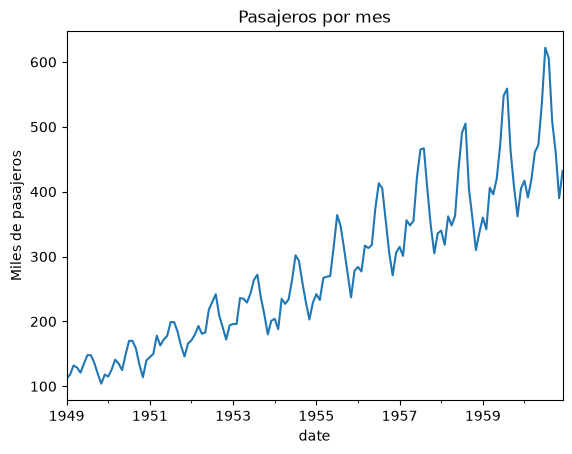

Tendencia creciente y oscilación anual cuya amplitud aumenta con el nivel.


In [4]:
y.plot(title='Pasajeros por mes');plt.ylabel('Miles de pasajeros');plt.show()
print('Tendencia creciente y oscilación anual cuya amplitud aumenta con el nivel.')

### Ejercicio 4

¿Podrías demostrar de dos maneras estadísticas que la serie no es estacionaria?

In [5]:
print('ADF, H0 raíz unitaria:',adfuller(y)[1])
print('KPSS, H0 estacionariedad:',kpss(y,regression='c',nlags='auto')[1])
print('ADF no rechaza raíz unitaria y KPSS rechaza estacionariedad al 5%: evidencias complementarias.')

ADF, H0 raíz unitaria: 0.9918802434376411
KPSS, H0 estacionariedad: 0.01
ADF no rechaza raíz unitaria y KPSS rechaza estacionariedad al 5%: evidencias complementarias.


C:\Users\Usuario\AppData\Local\Temp\ipykernel_15176\572550774.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  print('ADF, H0 raíz unitaria:',adfuller(y)[1])
C:\Users\Usuario\AppData\Local\Temp\ipykernel_15176\572550774.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  print('KPSS, H0 estacionariedad:',kpss(y,regression='c',nlags='auto')[1])
C:\Users\Usuario\AppData\Local\Temp\ipykernel_15176\572550774.py:2: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when stor

### Ejercicio 5

Emplea la descomposición que hemos aprendido en el workout para representar gráficamente la tendencia. Si has mostrado gráficamente la tendencia en el ejercicio 3, compara ambos.

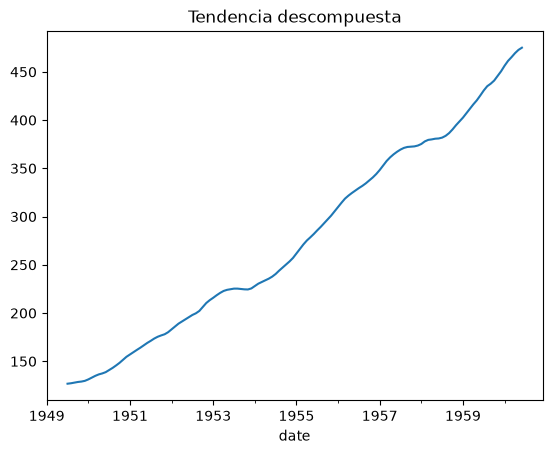

In [6]:
decomp=seasonal_decompose(y,model='multiplicative',period=12)
decomp.trend.plot(title='Tendencia descompuesta');plt.show()

### Ejercicio 6

Visualiza todos los componentes de la serie temporal por separado

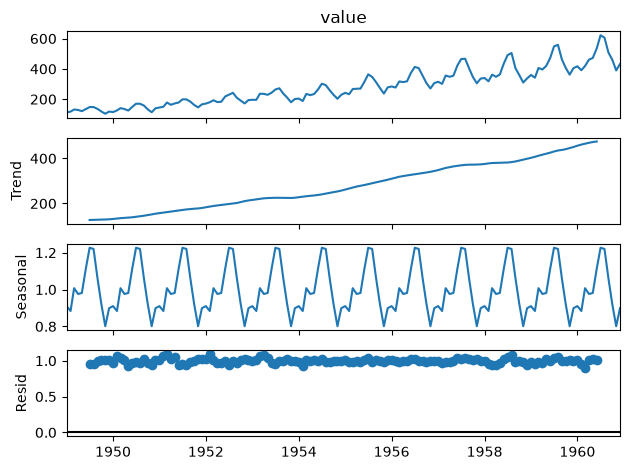

In [7]:
decomp.plot();plt.tight_layout();plt.show()

### Ejercicio 7

Crea una matriz de correlación con los últimos 24 instantes (matriz de autocorrelación). Crea un dataframe con shift de 1 a 24 para ello, la idea es que puedas hacer una matriz de correlación con el valor actual y los 24 valores anteriores. Es decir de un mes con sus 23 meses anteriores. Interpreta la estacionalidad

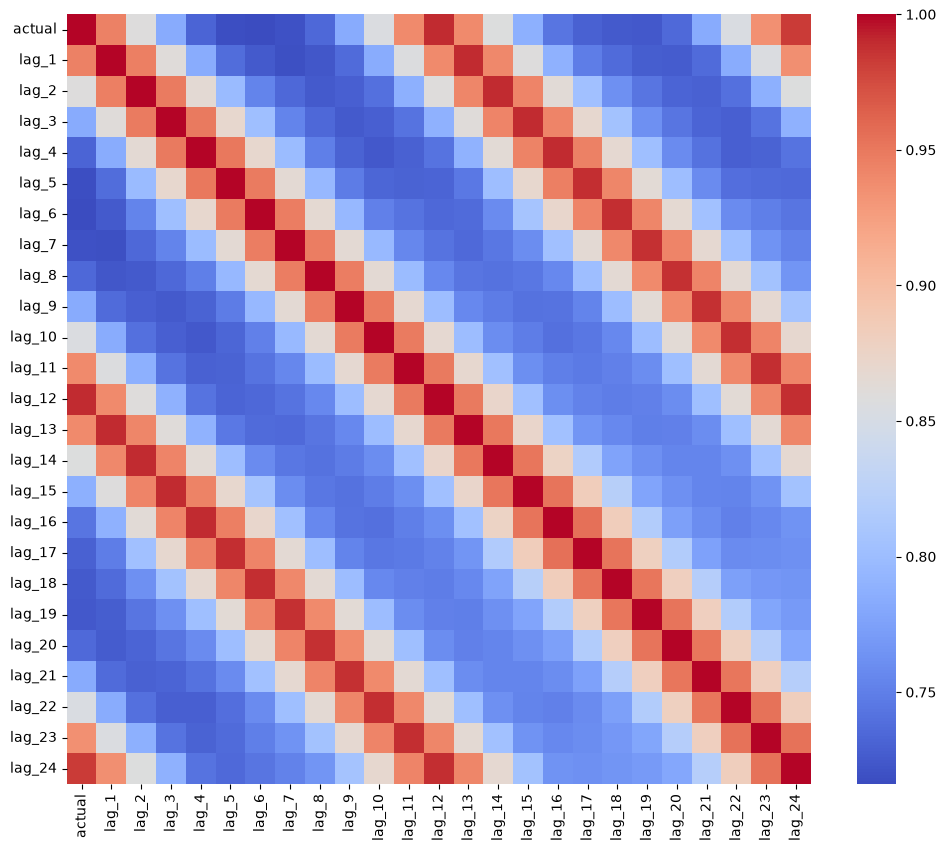

Correlación alta por tendencia; los múltiplos de 12 apoyan el ciclo anual, no prueban causalidad.


In [8]:
lags=pd.concat([y.rename('actual')]+[y.shift(i).rename(f'lag_{i}') for i in range(1,25)],axis=1).dropna()
plt.figure(figsize=(12,10));sns.heatmap(lags.corr(),cmap='coolwarm');plt.show()
print('Correlación alta por tendencia; los múltiplos de 12 apoyan el ciclo anual, no prueban causalidad.')

### Ejercicio 8
Ya hemos visto que hay seasonality. ¿Cada cuántos instantes se cumple ese patrón?

In [9]:
print('Estacionalidad: 12 meses.');display(y.groupby(y.index.month).mean())

Estacionalidad: 12 meses.


date
1     241.750000
2     235.000000
3     270.166667
4     267.083333
5     271.833333
6     311.666667
7     351.333333
8     351.083333
9     302.416667
10    266.583333
11    232.833333
12    261.833333
Name: value, dtype: float64

### Ejercicio 9

 Divide en train y test. En este caso no haremos división en validación, entre otras razones por la cantidad de datos que tenemos. Guarda 20 muestras para test.

In [10]:
train,test=y.iloc[:-20],y.iloc[-20:]
assert train.index.max()<test.index.min() and len(test)==20
print(len(train),len(test))

124 20


### Ejercicio 10

Pon en práctica lo visto en clases, crea un modelo de ARIMA (puedes utilizar autoarima), mide su RMSE y su MAPE. Comparalo gráficamente con los valores reales.

,modelo,RMSE,MAPE_pct
0,ARIMA,116.693399,18.149474


Orden elegido por AIC en train: (2, 1, 1)


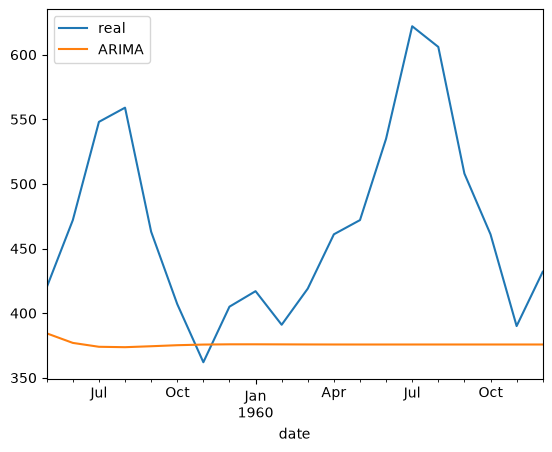

In [11]:
arima_candidates={order:ARIMA(np.log(train),order=order).fit() for order in [(1,1,0),(0,1,1),(1,1,1),(2,1,1)]}
arima=min(arima_candidates.values(),key=lambda m:m.aic)
pred_arima=pd.Series(np.exp(arima.forecast(len(test))).to_numpy(),index=test.index)
def evaluate(name,pred):
 return {'modelo':name,'RMSE':root_mean_squared_error(test,pred),'MAPE_pct':100*mean_absolute_percentage_error(test,pred)}
results=[evaluate('ARIMA',pred_arima)]
display(pd.DataFrame(results));print('Orden elegido por AIC en train:',arima.model.order)
test.plot(label='real');pred_arima.plot(label='ARIMA');plt.legend();plt.show()

### Ejercicio 11

Haz lo mismo que en el ejercicio 10 pero con un modelo SARIMA. ¿Cuál es mejor y por qué?

,modelo,RMSE,MAPE_pct
0,ARIMA,116.693399,18.149474
1,SARIMA,18.017604,3.506203
2,Naive estacional,77.404134,15.259058


SARIMA: (0, 1, 1) (0, 1, 1, 12)


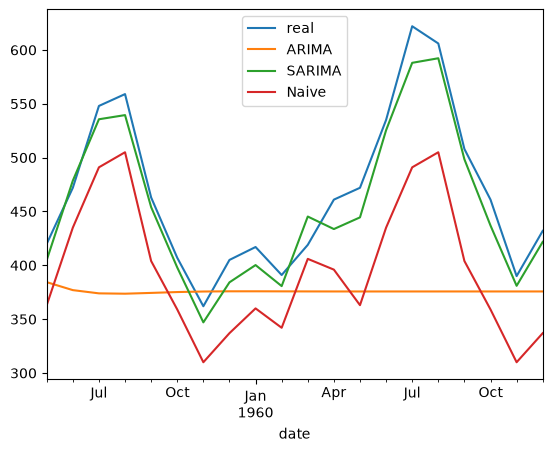

Menor RMSE en este test: SARIMA
SARIMA representa la periodicidad anual; la selección usa AIC de train. La inversa exponencial predice la mediana condicional, no una media corregida por sesgo.


In [12]:
candidates=[]
for order in [(0,1,1),(1,1,1)]:
 for seasonal in [(0,1,1,12),(1,1,0,12)]:
  fit=SARIMAX(np.log(train),order=order,seasonal_order=seasonal).fit(disp=False,maxiter=150)
  candidates.append(fit)
sarima=min(candidates,key=lambda m:m.aic)
pred_sarima=pd.Series(np.exp(sarima.forecast(len(test))).to_numpy(),index=test.index)
seasonal_naive=pd.Series(np.resize(train.iloc[-12:].to_numpy(),len(test)),index=test.index)
results.extend([evaluate('SARIMA',pred_sarima),evaluate('Naive estacional',seasonal_naive)])
display(pd.DataFrame(results));print('SARIMA:',sarima.model.order,sarima.model.seasonal_order)
test.plot(label='real');pred_arima.plot(label='ARIMA');pred_sarima.plot(label='SARIMA');seasonal_naive.plot(label='Naive');plt.legend();plt.show()
print('Menor RMSE en este test:',min(results,key=lambda r:r['RMSE'])['modelo'])
print('SARIMA representa la periodicidad anual; la selección usa AIC de train. La inversa exponencial predice la mediana condicional, no una media corregida por sesgo.')